# **Convolutional Neural Networks (CNNs): Fundamentals and Implementation**


---

## **Learning Objectives**

By the end of this tutorial, students will be able to:

1. **Understand** why CNNs are essential for image processing tasks
2. **Differentiate** between CNNs and traditional MLPs
3. **Explain** the core concepts behind CNNs: convolution operations, weight sharing, and translational invariance
4. **Implement** CNN components: convolutional layers, pooling layers, and fully connected layers
5. **Build** and train complete CNN architectures using PyTorch
6. **Visualize** feature maps and filters to understand what CNNs are learning
7. **Apply** CNNs to solve real image classification problems

---

## **Prerequisites**

- Understanding of basic neural network concepts
- Familiarity with Python programming and NumPy
- Basic knowledge of machine learning concepts
- Introduction to PyTorch tensors and autograd (recommended)

## **1. Why Do We Need CNNs?**

### **1.1 Limitations of Multi-Layer Perceptrons (MLPs) for Images**

Traditional MLPs face several significant challenges when dealing with image data:

**1. Parameter Explosion**:
- A single 224×224×3 color image has 150,528 pixels
- If the first hidden layer has just 100 neurons, we'd need 15,052,800 parameters (weights) just for the first layer!
- This leads to computational inefficiency and excessive memory requirements

**2. Spatial Information Loss**:
- MLPs flatten images into 1D vectors, destroying spatial relationships
- The fact that adjacent pixels are related in an image is completely ignored
- Location information about features (edges, textures, shapes) is lost

**3. Translation Variance**:
- MLPs don't handle translations well - an object shifted slightly in an image appears as a completely different input
- A dog in the left corner vs. center would require learning separate representations
- This forces the model to see many examples of objects in different positions

**4. Data Inefficiency**:
- Without built-in inductive biases for images, MLPs require enormous datasets
- Need to learn the same patterns multiple times in different locations
- Prone to overfitting with limited training data

### **1.2 CNN Advantage: Built for Visual Data**

CNNs address these limitations with specialized architectural components:

**1. Parameter Efficiency**:
- Small, learnable filter kernels shared across the entire image
- Drastically reduces parameter count (e.g., 3×3 filter = 9 parameters regardless of image size)
- Example: First layer of AlexNet has ~200x fewer parameters than equivalent MLP

**2. Spatial Awareness**:
- Maintains 2D/3D structure of input data throughout processing
- Processes local regions (receptive fields) that preserve spatial relationships
- Hierarchically builds up understanding from pixels to edges to textures to objects

**3. Translation Invariance**:
- Same feature detector applied across entire image (weight sharing)
- Can detect features regardless of their position in the image
- Built-in capability to handle object translations

**4. Data Efficiency**:
- Strong inductive bias for visual tasks requiring fewer examples
- Feature reuse across different spatial locations
- Better generalization from limited training data

These advantages make CNNs the backbone of modern computer vision, enabling breakthrough performance in image classification, object detection, segmentation, and many other visual tasks.

### **1.3 CNNs vs MLPs: Direct Comparison**

| **Aspect** | **Multi-Layer Perceptron (MLP)** | **Convolutional Neural Network (CNN)** |
|------------|----------------------------------|---------------------------------------|
| **Architecture** | Fully connected layers only | Convolutional, pooling, and fully connected layers |
| **Input Handling** | Flattens 2D/3D data to 1D vectors | Preserves spatial structure of input data |
| **Parameters** | One weight per input-output connection | Shared weights via convolutional filters |
| **Parameter Count** | Very high for image data (millions to billions) | Much lower (thousands to millions) |
| **Spatial Awareness** | None; treats each pixel independently | Strong spatial awareness through local receptive fields |
| **Translation Handling** | Poor; must learn patterns at each position | Good; can detect patterns regardless of position |
| **Feature Learning** | Global features only | Hierarchical: edges → textures → patterns → objects |
| **Training Data Requirements** | Requires enormous datasets for visual tasks | Can learn effectively with smaller datasets |
| **Computation** | Simple matrix multiplications | Convolution operations (can be parallelized on GPUs) |
| **Typical Applications** | Tabular data, simple classification | Images, videos, any data with spatial/temporal structure |

This fundamental difference in architecture makes CNNs vastly superior for processing images and other data with spatial structure, while MLPs remain useful for problems where inputs have no inherent spatial relationship.

In [1]:
# Essential imports for deep learning and visualization
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

# Data science and visualization libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Configure matplotlib for better visualization
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Using device: {device}")

if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("   Running on CPU")

print(f"\n📦 Library Versions:")
print(f"   PyTorch: {torch.__version__}")
print(f"   NumPy: {np.__version__}")
print(f"   Matplotlib: {plt.matplotlib.__version__}")

print("\n✅ Environment setup complete!")

🚀 Using device: cpu
   Running on CPU

📦 Library Versions:
   PyTorch: 2.10.0+cpu
   NumPy: 2.4.1
   Matplotlib: 3.10.8

✅ Environment setup complete!


## **2. Core Concepts of Convolutional Neural Networks**

### **2.1 The Convolution Operation: The Building Block of CNNs**

The convolution operation is the fundamental building block that gives CNNs their name and power. It involves sliding a small filter (or kernel) across an input image and computing element-wise multiplications followed by summation.

**Mathematical Definition:**

For a 2D input image $I$ and a 2D kernel $K$, the convolution operation is defined as:

$$(I * K)(i, j) = \sum_m \sum_n I(i+m, j+n) \cdot K(m, n)$$

Where:
- $I$ is the input image or feature map
- $K$ is the convolution kernel/filter
- $*$ denotes the convolution operation
- $(i,j)$ are the coordinates in the output feature map

**Key Properties:**

1. **Local Receptive Field**: Each neuron in a convolutional layer connects only to a small region of the input
2. **Learnable Filters**: The values in each filter are learnable parameters updated during training
3. **Feature Detection**: Different filters learn to detect different features (edges, textures, patterns)
4. **Activation Maps**: The output of a convolution is called a feature map or activation map

**Important Hyperparameters:**

- **Filter Size**: Typically odd numbers like 3×3, 5×5, 7×7 (provides a center pixel)
- **Stride**: How many pixels to move the filter at each step (default is 1)
- **Padding**: Adding pixels around the input to control output dimensions
- **Number of Filters**: Each filter produces one feature map (more filters = more features)

=== Horizontal Edge Detection Kernel ===


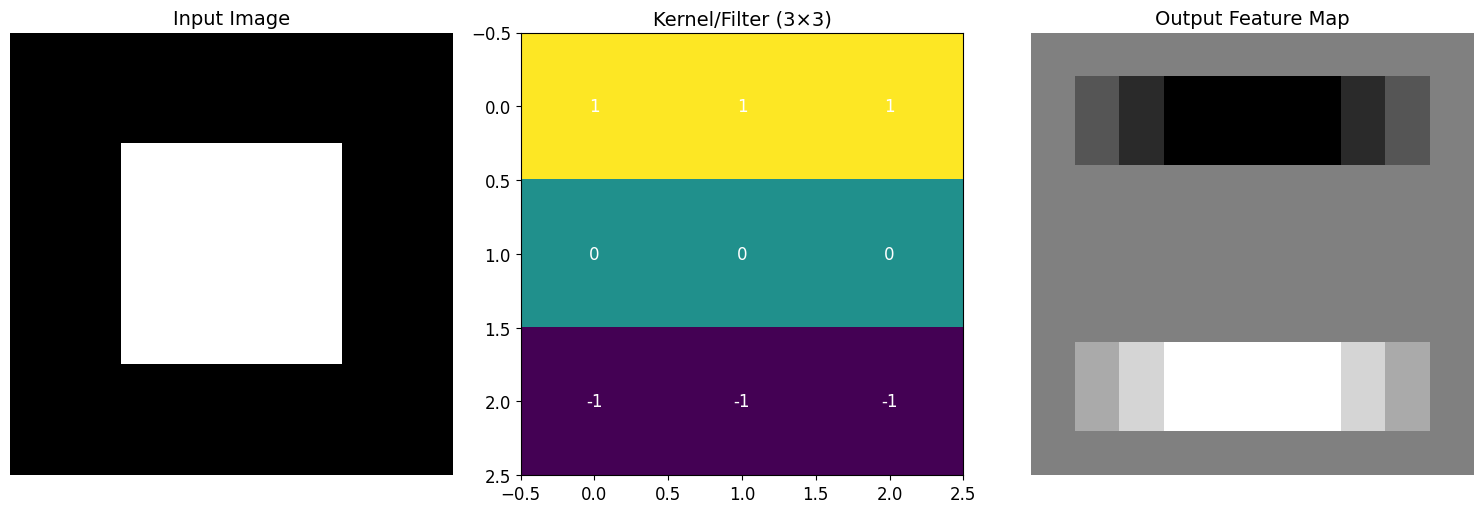

=== Vertical Edge Detection Kernel ===


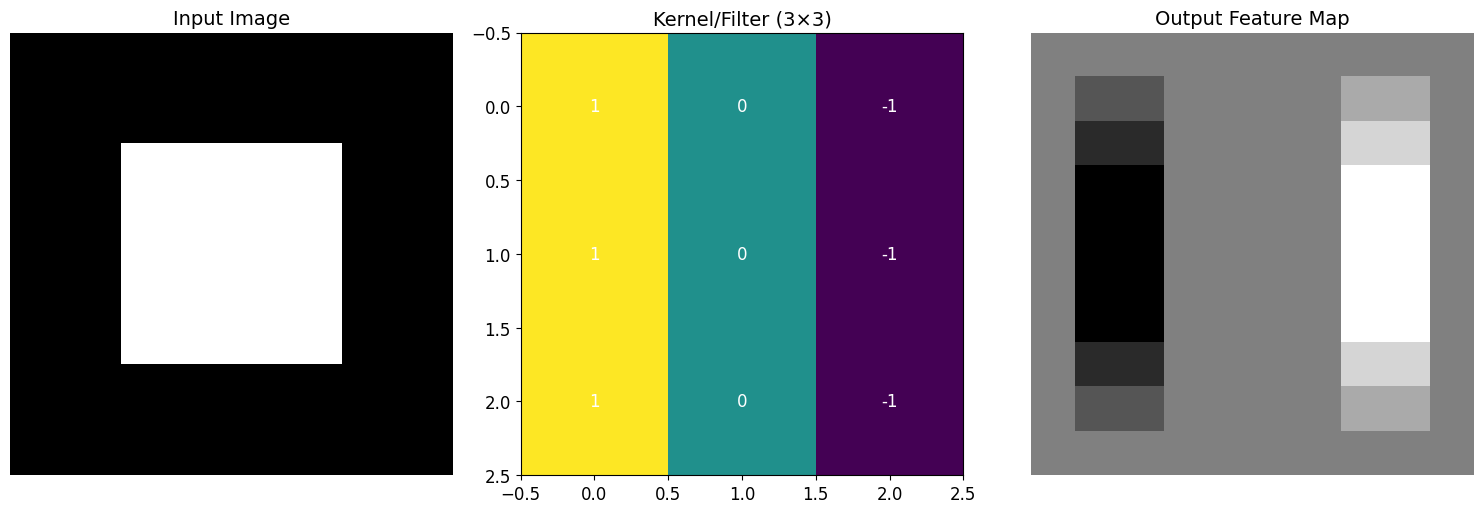

=== Sharpening Kernel ===


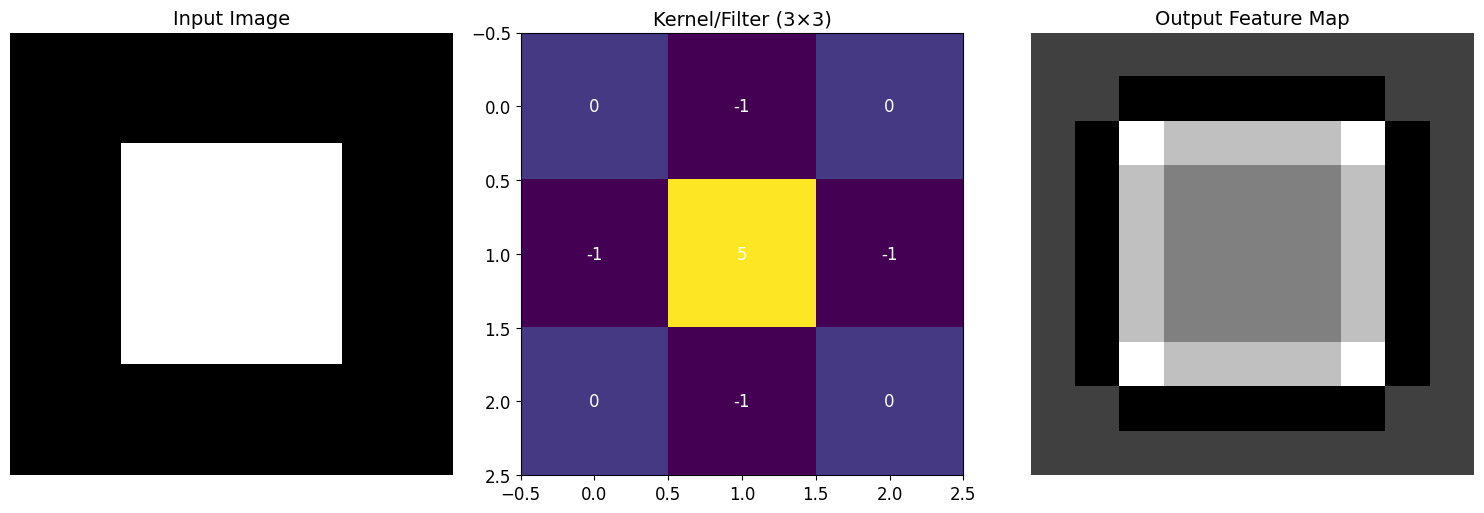

In [2]:
# Visualization of convolution operation
def visualize_convolution(image, kernel, feature_map):
    """Visualize the convolution operation with an image, kernel, and resulting feature map."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Display the input image
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title('Input Image', fontsize=14)
    axes[0].axis('off')

    # Display the kernel/filter
    # Use a diverging colormap for kernels with positive and negative values
    axes[1].imshow(kernel, cmap='viridis')
    axes[1].set_title(f'Kernel/Filter ({kernel.shape[0]}×{kernel.shape[1]})', fontsize=14)
    # Add annotations for kernel values
    for i in range(kernel.shape[0]):
        for j in range(kernel.shape[1]):
            axes[1].text(j, i, f'{kernel[i, j]}', ha='center', va='center', color='white', fontsize=12)

    # Display the resulting feature map
    axes[2].imshow(feature_map, cmap='gray')
    axes[2].set_title('Output Feature Map', fontsize=14)
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# Create a simple 12x12 image with a white square
# This pattern has clear horizontal and vertical edges, perfect for this demo.
image = np.zeros((12, 12))
image[3:9, 3:9] = 1 # A 6x6 white square in the middle

# Define different kernels to demonstrate filter effects
kernels = {
    "Horizontal Edge Detection": np.array([
        [1, 1, 1],
        [0, 0, 0],
        [-1, -1, -1]
    ]),
    "Vertical Edge Detection": np.array([
        [1, 0, -1],
        [1, 0, -1],
        [1, 0, -1]
    ]),
    "Sharpening": np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
    ])
}

# Manual 2D convolution for demonstration
def convolve2d_manual(image, kernel):
    # Get dimensions
    i_height, i_width = image.shape
    k_height, k_width = kernel.shape

    # Calculate output dimensions (assuming 'valid' convolution without padding)
    o_height = i_height - k_height + 1
    o_width = i_width - k_width + 1

    # Initialize output feature map
    output = np.zeros((o_height, o_width))

    # Perform convolution
    for i in range(o_height):
        for j in range(o_width):
            # Extract the current window
            window = image[i:i+k_height, j:j+k_width]
            # Element-wise multiplication and sum
            output[i, j] = np.sum(window * kernel)

    return output

# Display convolution results for each kernel
for name, kernel in kernels.items():
    # Apply convolution
    feature_map = convolve2d_manual(image, kernel)

    # Normalize feature map for better visualization (maps values to [0, 1])
    # Add a small epsilon to avoid division by zero if the feature map is flat
    f_min, f_max = feature_map.min(), feature_map.max()
    if f_max - f_min > 1e-8:
        feature_map = (feature_map - f_min) / (f_max - f_min)
    else:
        # If the map is all one value, just set it to a uniform gray
        feature_map = np.full_like(feature_map, 0.5)


    print(f"=== {name} Kernel ===")
    visualize_convolution(image, kernel, feature_map)

### **2.2 Weight Sharing: The Parameter-Efficient Innovation**

**Weight sharing** is a fundamental property of CNNs that dramatically reduces the number of parameters while enabling powerful feature detection.

**Key Concepts:**

1. **Filter Reuse Across Space**:
   - Each filter is applied to every position in the input
   - The same set of weights is used regardless of where in the image a feature appears
   - Drastically reduces the number of learnable parameters

2. **Parameter Efficiency**:
   - For a single 3×3 convolutional filter: only 9 weights (plus 1 bias)
   - In contrast, a fully connected layer processing a 28×28 image would need 784 weights per neuron
   - For 64 filters: CNN = 640 parameters vs MLP = 50,176 parameters

3. **Biological Inspiration**:
   - Mimics the human visual cortex where similar feature detectors are repeated across the visual field
   - Neurons in visual cortex respond to the same feature regardless of its position

**Computational Benefits:**
   - Reduced memory footprint
   - Faster training
   - Less prone to overfitting
   - Better generalization

### **2.3 Translational Invariance: Detecting Features Anywhere**

**Translational invariance** (more accurately, translational equivariance) means the network can detect features regardless of their position in the image.

**How CNNs Achieve This:**

1. **Convolution Layers**: Create translational equivariance
   - If a feature moves in the input, its representation moves correspondingly in the feature maps
   - The same feature is detected regardless of its position

2. **Pooling Layers**: Enhance translational invariance
   - Reduce sensitivity to exact position by summarizing regions
   - Allow for small spatial variations while preserving important features

**Real-World Example:**
   - A face detection CNN can identify faces regardless of whether they appear in the top-left, center, or bottom-right of an image
   - No need to train separate detectors for each position

**Why It Matters:**
   - Objects in the real world appear in different positions
   - Enables more efficient learning - pattern recognized once can be recognized everywhere
   - Makes CNNs robust to spatial transformations in the input

### **2.4 Pooling Layers: Downsampling and Spatial Invariance**

Pooling layers are used to progressively reduce the spatial dimensions of the representation, reducing computation and controlling overfitting.

**Types of Pooling:**

1. **Max Pooling**:
   - Takes the maximum value from a local region
   - Most commonly used in practice
   - Helps extract the most prominent features
   - Example: 2×2 max pooling with stride 2 halves both dimensions

2. **Average Pooling**:
   - Takes the average value from a local region
   - Preserves more background information
   - Sometimes used in the final layers of networks

3. **Global Pooling**:
   - Reduces each feature map to a single value (max or average)
   - Often used before fully connected layers
   - Makes the network accept inputs of variable size

**Benefits of Pooling:**

1. **Dimensionality Reduction**:
   - Reduces computation and parameters in subsequent layers
   - Controls memory usage in deep networks

2. **Feature Robustness**:
   - Provides invariance to small translations and distortions
   - Helps the network focus on whether a feature is present rather than exactly where

3. **Increased Receptive Field**:
   - Each neuron in deeper layers can "see" a larger portion of the input
   - Enables detection of larger-scale features in deeper layers

**Example**: A 2×2 max pooling operation with stride 2:

```
Input:          Output:
┌───┬───┬───┬───┐      ┌───┬───┐
│ 1 │ 3 │ 2 │ 5 │      │ 9 │ 8 │
├───┼───┼───┼───┤  →   ├───┼───┤
│ 9 │ 7 │ 8 │ 6 │      │ 4 │ 7 │
├───┼───┼───┼───┤      └───┴───┘
│ 4 │ 2 │ 7 │ 3 │
├───┼───┼───┼───┤
│ 1 │ 0 │ 5 │ 2 │
└───┴───┴───┴───┘
```

**Pooling Hyperparameters:**
- **Pool size**: Dimensions of the pooling window (typically 2×2)
- **Stride**: Step size for moving the window (typically equal to pool size)
- **Padding**: Rarely used in pooling layers

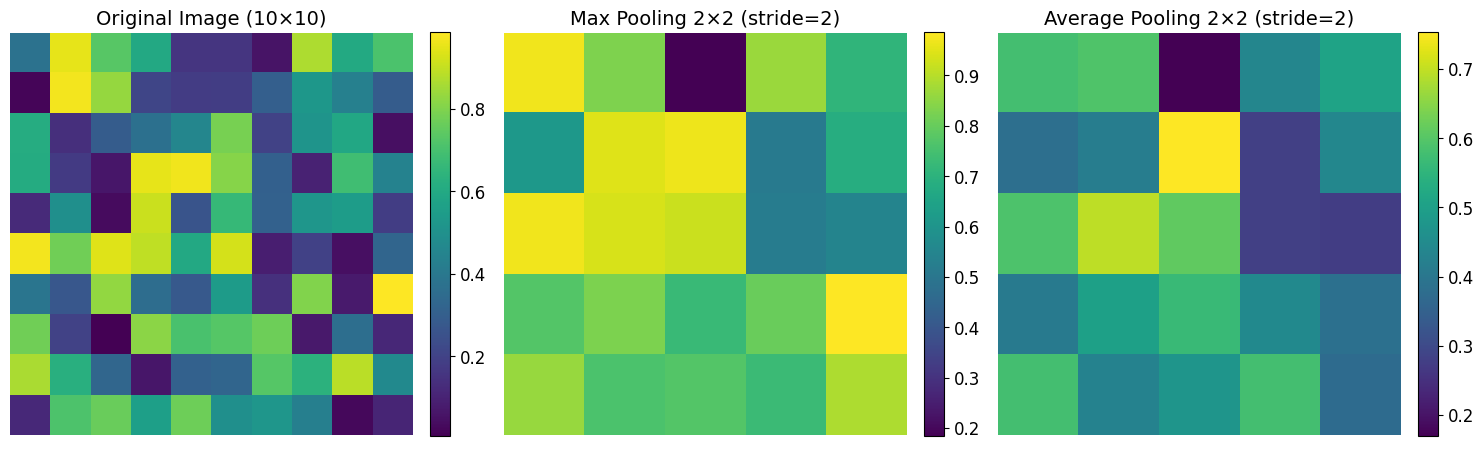

Original 4×4 matrix:
[[1 3 2 5]
 [9 7 8 6]
 [4 2 7 3]
 [1 0 5 2]]


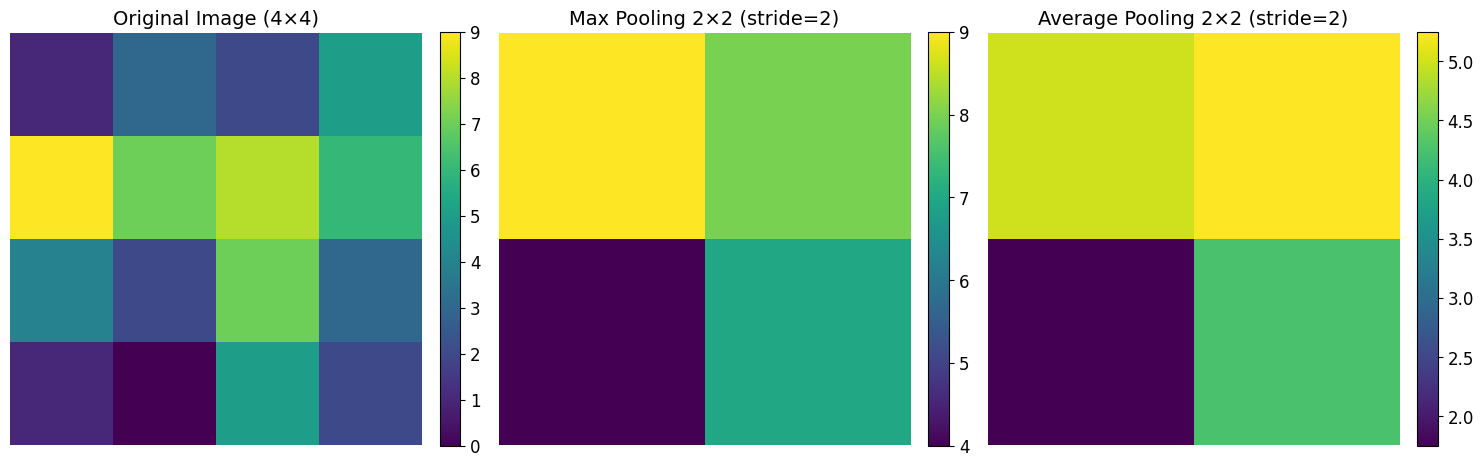

In [3]:
# Demonstration of pooling operations
def visualize_pooling(image, pool_size=2, stride=2):
    """Visualize max and average pooling operations."""

    # Manual implementation of pooling operations
    def max_pool(image, pool_size, stride):
        h, w = image.shape
        h_out = (h - pool_size) // stride + 1
        w_out = (w - pool_size) // stride + 1
        result = np.zeros((h_out, w_out))

        for i in range(0, h_out):
            for j in range(0, w_out):
                result[i, j] = np.max(image[i*stride:i*stride+pool_size, j*stride:j*stride+pool_size])
        return result

    def avg_pool(image, pool_size, stride):
        h, w = image.shape
        h_out = (h - pool_size) // stride + 1
        w_out = (w - pool_size) // stride + 1
        result = np.zeros((h_out, w_out))

        for i in range(0, h_out):
            for j in range(0, w_out):
                result[i, j] = np.mean(image[i*stride:i*stride+pool_size, j*stride:j*stride+pool_size])
        return result

    # Apply pooling operations
    max_pooled = max_pool(image, pool_size, stride)
    avg_pooled = avg_pool(image, pool_size, stride)

    # Visualize results
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Display original image
    im0 = axes[0].imshow(image, cmap='viridis')
    axes[0].set_title(f'Original Image ({image.shape[0]}×{image.shape[1]})', fontsize=14)
    axes[0].axis('off')
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    # Display max pooled result
    im1 = axes[1].imshow(max_pooled, cmap='viridis')
    axes[1].set_title(f'Max Pooling {pool_size}×{pool_size} (stride={stride})', fontsize=14)
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    # Display average pooled result
    im2 = axes[2].imshow(avg_pooled, cmap='viridis')
    axes[2].set_title(f'Average Pooling {pool_size}×{pool_size} (stride={stride})', fontsize=14)
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

# Generate a more complex test image (10x10)
np.random.seed(42)
test_image = np.random.rand(10, 10)

# Visualize pooling operations
visualize_pooling(test_image, pool_size=2, stride=2)

# Create a specific example to illustrate the behavior
example = np.array([
    [1, 3, 2, 5],
    [9, 7, 8, 6],
    [4, 2, 7, 3],
    [1, 0, 5, 2]
])

print("Original 4×4 matrix:")
print(example)

# Apply pooling to our example
visualize_pooling(example, pool_size=2, stride=2)

### **2.5 Complete CNN Architecture**

A typical CNN architecture combines multiple types of layers to create a powerful feature extractor followed by a classifier:

**Standard Layer Sequence:**

1. **Input Layer**: Holds the raw pixel values (H×W×C format)
   - H: Height, W: Width, C: Channels (3 for RGB, 1 for grayscale)

2. **Convolutional Layers**: Extract visual features
   - Multiple filters detect different features
   - Each filter produces one feature map
   - Activation function (typically ReLU) introduces non-linearity

3. **Pooling Layers**: Downsample feature maps
   - Reduce spatial dimensions
   - Typically after conv layers
   - Make features more robust to small variations

4. **Multiple Conv+Pool Blocks**: Form feature hierarchy
   - Early layers: detect simple features (edges, corners)
   - Middle layers: textures, patterns
   - Later layers: complex objects, parts

5. **Flattening Layer**: Transition from 2D to 1D
   - Converts 2D feature maps to 1D feature vector

6. **Fully Connected Layers**: Classification/regression
   - Traditional neural network layers
   - Combine features for final prediction
   - Often include dropout for regularization

7. **Output Layer**: Final predictions
   - Classification: Softmax activation (multi-class) or sigmoid (binary)
   - Regression: Linear activation

**Common CNN Design Patterns:**

- **Increase filters, decrease spatial dimensions**: As we go deeper, number of filters increases while spatial dimensions decrease
- **Bottleneck structures**: Reduce computational complexity by inserting 1×1 convolutions
- **Skip connections**: Connect layers that aren't adjacent (as in ResNet)
- **Network-in-Network**: Use 1×1 convolutions to add depth without increasing parameters

**Example of a Simple CNN Architecture for MNIST:**

```
Input: 28×28×1 (grayscale image)
↓
Conv1: 3×3 filters, 32 channels, ReLU → 26×26×32
↓
MaxPool1: 2×2 pool, stride 2 → 13×13×32
↓
Conv2: 3×3 filters, 64 channels, ReLU → 11×11×64
↓
MaxPool2: 2×2 pool, stride 2 → 5×5×64
↓
Conv3: 3×3 filters, 128 channels, ReLU → 3×3×128
↓
Flatten → 1152 features
↓
FC1: 128 neurons, ReLU
↓
Dropout: p=0.5
↓
FC2: 10 neurons, Softmax (output layer)
```

In the following sections, we'll implement this architecture in PyTorch and explore its behavior on a real dataset.

## **3. Implementation of CNN Components with PyTorch**

PyTorch provides all the building blocks needed to create CNNs. Let's explore the implementation of each component.

### **3.1 Convolutional Layers in PyTorch**

PyTorch's `nn.Conv2d` implements the 2D convolution operation for images:

Conv2d Layer Parameters:
  in_channels: 1
  out_channels: 6
  kernel_size: (3, 3)
  stride: (1, 1)
  padding: (0, 0)

Input Shape: torch.Size([1, 1, 28, 28])
Output Shape: torch.Size([1, 6, 26, 26])
Expected Output Shape: [1, 6, 26, 26]

Parameter Count:
  Weights: 54 (1 × 6 × 3 × 3)
  Biases: 6 (one per output channel)
  Total: 60 parameters


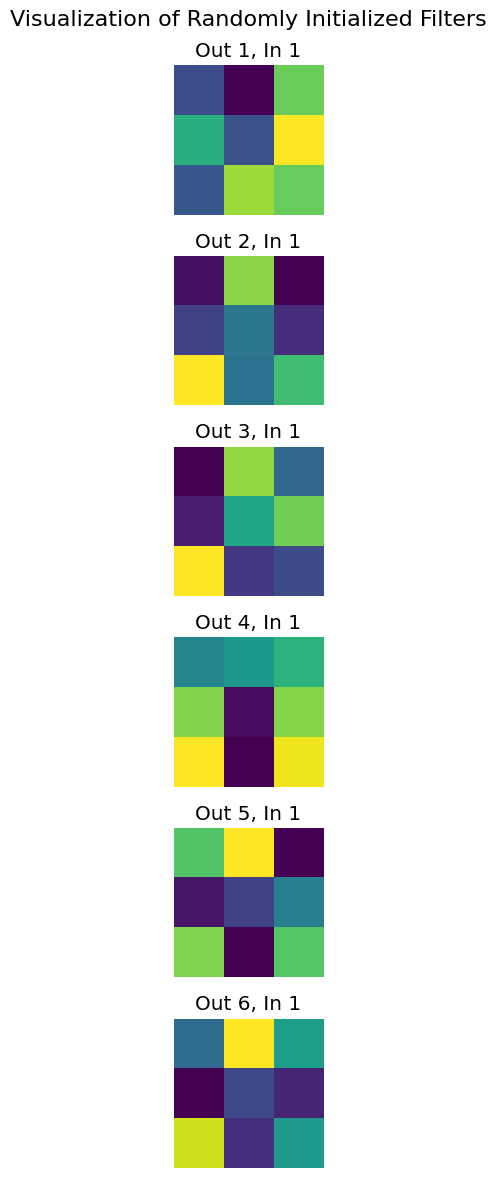

Conv2d Layer Parameters:
  in_channels: 1
  out_channels: 6
  kernel_size: (3, 3)
  stride: (1, 1)
  padding: (1, 1)

Input Shape: torch.Size([1, 1, 28, 28])
Output Shape: torch.Size([1, 6, 28, 28])
Expected Output Shape: [1, 6, 28, 28]

Parameter Count:
  Weights: 54 (1 × 6 × 3 × 3)
  Biases: 6 (one per output channel)
  Total: 60 parameters


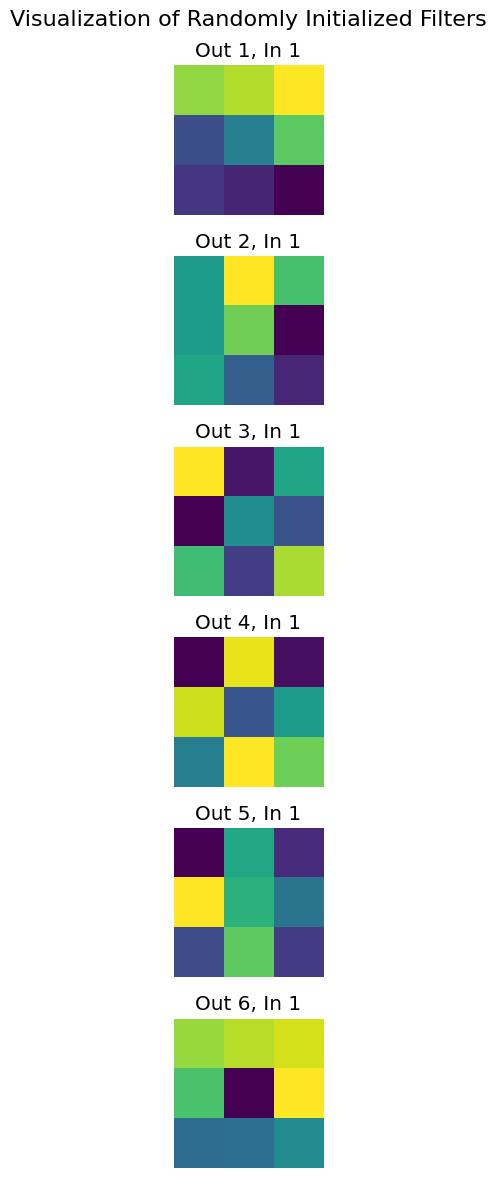

Conv2d Layer Parameters:
  in_channels: 1
  out_channels: 6
  kernel_size: (3, 3)
  stride: (2, 2)
  padding: (0, 0)

Input Shape: torch.Size([1, 1, 28, 28])
Output Shape: torch.Size([1, 6, 13, 13])
Expected Output Shape: [1, 6, 13, 13]

Parameter Count:
  Weights: 54 (1 × 6 × 3 × 3)
  Biases: 6 (one per output channel)
  Total: 60 parameters


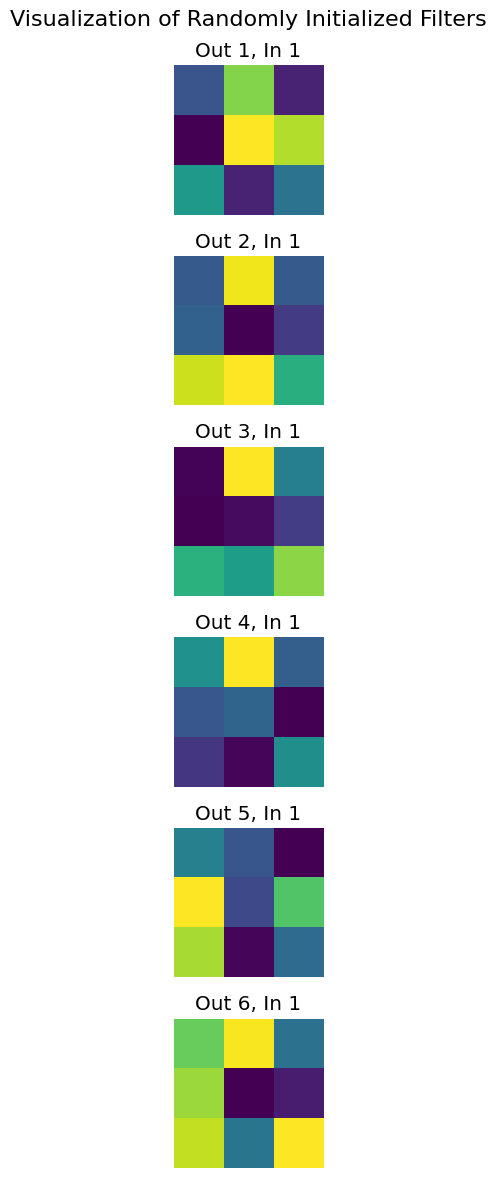

Conv2d Layer Parameters:
  in_channels: 3
  out_channels: 6
  kernel_size: (3, 3)
  stride: (1, 1)
  padding: (1, 1)

Input Shape: torch.Size([1, 3, 28, 28])
Output Shape: torch.Size([1, 6, 28, 28])
Expected Output Shape: [1, 6, 28, 28]

Parameter Count:
  Weights: 162 (3 × 6 × 3 × 3)
  Biases: 6 (one per output channel)
  Total: 168 parameters


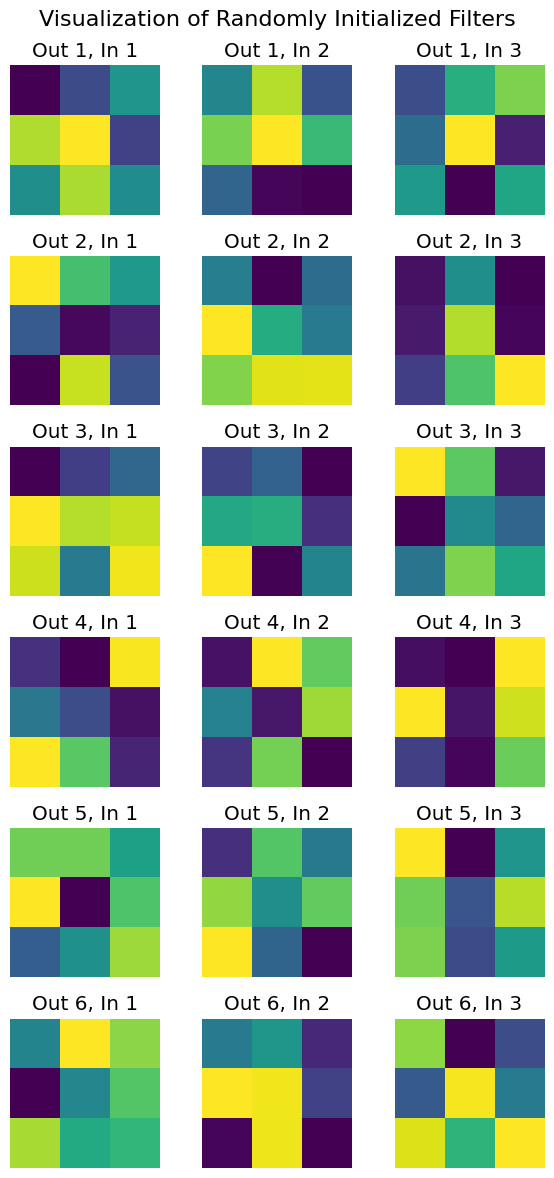

In [4]:
# Understanding nn.Conv2d parameters
def explore_conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0):
    """Explore the behavior of a convolutional layer with specified parameters."""

    # Create a random input tensor
    batch_size = 1
    input_height, input_width = 28, 28  # Like MNIST
    x = torch.randn(batch_size, in_channels, input_height, input_width)

    # Create convolutional layer
    conv_layer = nn.Conv2d(
        in_channels=in_channels,
        out_channels=out_channels,
        kernel_size=kernel_size,
        stride=stride,
        padding=padding
    )

    # Apply convolution
    output = conv_layer(x)

    # Calculate theoretical output size
    output_height = ((input_height + 2 * padding - kernel_size) // stride) + 1
    output_width = ((input_width + 2 * padding - kernel_size) // stride) + 1

    # Print information
    print(f"Conv2d Layer Parameters:")
    print(f"  in_channels: {in_channels}")
    print(f"  out_channels: {out_channels}")
    print(f"  kernel_size: {kernel_size if isinstance(kernel_size, tuple) else (kernel_size, kernel_size)}")
    print(f"  stride: {stride if isinstance(stride, tuple) else (stride, stride)}")
    print(f"  padding: {padding if isinstance(padding, tuple) else (padding, padding)}")
    print("\nInput Shape:", x.shape)
    print("Output Shape:", output.shape)
    print(f"Expected Output Shape: [1, {out_channels}, {output_height}, {output_width}]")

    # Count parameters
    total_params = sum(p.numel() for p in conv_layer.parameters())
    weights_size = in_channels * out_channels * kernel_size * kernel_size
    bias_size = out_channels
    print(f"\nParameter Count:")
    print(f"  Weights: {weights_size:,} ({in_channels} × {out_channels} × {kernel_size} × {kernel_size})")
    print(f"  Biases: {bias_size:,} (one per output channel)")
    print(f"  Total: {total_params:,} parameters")

    # Access and visualize weights
    if out_channels <= 6 and in_channels <= 3:  # Keep visualization manageable
        weights = conv_layer.weight.data.numpy()

        # Create a grid for displaying filters
        fig, axes = plt.subplots(out_channels, in_channels,
                                figsize=(2*in_channels, 2*out_channels),
                                squeeze=False)

        for i in range(out_channels):
            for j in range(in_channels):
                # Get the filter weights
                filter_weights = weights[i, j]

                # Display the filter
                im = axes[i, j].imshow(filter_weights, cmap='viridis')
                axes[i, j].set_title(f"Out {i+1}, In {j+1}")
                axes[i, j].axis('off')

        plt.suptitle("Visualization of Randomly Initialized Filters", fontsize=16)
        plt.tight_layout()
        plt.show()

# Example 1: Basic convolution - 1 input channel, 6 output channels, 3×3 kernel
explore_conv2d(in_channels=1, out_channels=6, kernel_size=3)

# Example 2: Convolution with padding to maintain spatial dimensions
explore_conv2d(in_channels=1, out_channels=6, kernel_size=3, padding=1)

# Example 3: Convolution with stride to reduce spatial dimensions
explore_conv2d(in_channels=1, out_channels=6, kernel_size=3, stride=2)

# Example 4: RGB image input (3 channels)
explore_conv2d(in_channels=3, out_channels=6, kernel_size=3, padding=1)

### **3.2 Pooling Layers in PyTorch**

PyTorch provides different types of pooling operations through its `nn` module:

Input Feature Map (6×6):
[[ 1.  2.  3.  4.  5.  6.]
 [ 7.  8.  9. 10. 11. 12.]
 [13. 14. 15. 16. 17. 18.]
 [19. 20. 21. 22. 23. 24.]
 [25. 26. 27. 28. 29. 30.]
 [31. 32. 33. 34. 35. 36.]]

MaxPool2d Output (2×2, stride=2):
[[ 8. 10. 12.]
 [20. 22. 24.]
 [32. 34. 36.]]

AvgPool2d Output (2×2, stride=2):
[[ 4.5  6.5  8.5]
 [16.5 18.5 20.5]
 [28.5 30.5 32.5]]

Global Max Pooling Output:
36.0

Global Average Pooling Output:
18.5


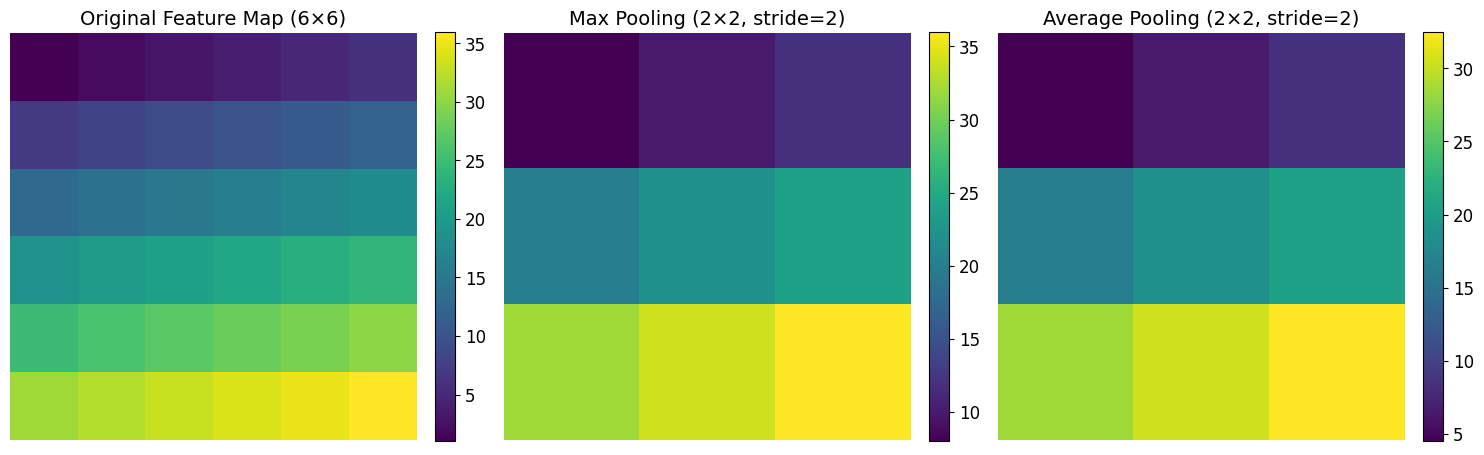

In [5]:
# Explore different pooling operations in PyTorch
def explore_pooling():
    """Demonstrate different pooling operations in PyTorch."""

    # Create a sample feature map (1 batch, 1 channel, 6x6)
    feature_map = torch.tensor([
        [1.0, 2.0, 3.0, 4.0, 5.0, 6.0],
        [7.0, 8.0, 9.0, 10.0, 11.0, 12.0],
        [13.0, 14.0, 15.0, 16.0, 17.0, 18.0],
        [19.0, 20.0, 21.0, 22.0, 23.0, 24.0],
        [25.0, 26.0, 27.0, 28.0, 29.0, 30.0],
        [31.0, 32.0, 33.0, 34.0, 35.0, 36.0]
    ]).unsqueeze(0).unsqueeze(0)  # Add batch and channel dimensions

    print("Input Feature Map (6×6):")
    print(feature_map.squeeze().numpy())
    print()

    # Define pooling operations
    max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
    avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)

    # Apply pooling
    max_result = max_pool(feature_map)
    avg_result = avg_pool(feature_map)

    print("MaxPool2d Output (2×2, stride=2):")
    print(max_result.squeeze().numpy())
    print()

    print("AvgPool2d Output (2×2, stride=2):")
    print(avg_result.squeeze().numpy())
    print()

    # Global pooling
    global_max = nn.AdaptiveMaxPool2d(1)
    global_avg = nn.AdaptiveAvgPool2d(1)

    global_max_result = global_max(feature_map)
    global_avg_result = global_avg(feature_map)

    print("Global Max Pooling Output:")
    print(global_max_result.squeeze().item())
    print()

    print("Global Average Pooling Output:")
    print(global_avg_result.squeeze().item())

    # Visual comparison
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Original feature map
    im0 = axes[0].imshow(feature_map.squeeze(), cmap='viridis')
    axes[0].set_title("Original Feature Map (6×6)", fontsize=14)
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
    axes[0].axis('off')

    # Max pooling result
    im1 = axes[1].imshow(max_result.squeeze(), cmap='viridis')
    axes[1].set_title("Max Pooling (2×2, stride=2)", fontsize=14)
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    axes[1].axis('off')

    # Average pooling result
    im2 = axes[2].imshow(avg_result.squeeze(), cmap='viridis')
    axes[2].set_title("Average Pooling (2×2, stride=2)", fontsize=14)
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# Execute the exploration
explore_pooling()

### **3.3 Building a Complete CNN Model in PyTorch**

Now let's implement a complete CNN model for image classification. We'll use the architecture described earlier, designed for the MNIST or Fashion-MNIST dataset.

In [6]:
# Define a CNN model for MNIST/Fashion-MNIST classification
class SimpleCNN(nn.Module):
    def __init__(self):
        """Initialize the layers of our CNN."""
        super(SimpleCNN, self).__init__()

        # First convolutional block
        self.conv1 = nn.Conv2d(
            in_channels=1,         # Grayscale input
            out_channels=32,       # 32 filters
            kernel_size=3,         # 3×3 kernel
            stride=1,              # Default stride
            padding=1              # Keep spatial dimensions
        )
        self.relu1 = nn.ReLU()     # ReLU activation
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # 2×2 max pooling

        # Second convolutional block
        self.conv2 = nn.Conv2d(
            in_channels=32,        # Input from previous layer
            out_channels=64,       # 64 filters
            kernel_size=3,         # 3×3 kernel
            stride=1,              # Default stride
            padding=1              # Keep spatial dimensions
        )
        self.relu2 = nn.ReLU()     # ReLU activation
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)  # 2×2 max pooling

        # Third convolutional block
        self.conv3 = nn.Conv2d(
            in_channels=64,        # Input from previous layer
            out_channels=128,      # 128 filters
            kernel_size=3,         # 3×3 kernel
            stride=1,              # Default stride
            padding=1              # Keep spatial dimensions
        )
        self.relu3 = nn.ReLU()     # ReLU activation
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)  # 2×2 max pooling

        # Calculate the size after convolutions and pooling
        # Input: 28×28 -> After 3 pools with stride 2: 28/(2^3) = 28/8 = 3.5 -> 3×3
        # So we have 3×3×128 = 1152 features

        # Fully connected layers
        self.fc1 = nn.Linear(3 * 3 * 128, 128)  # Flatten and reduce to 128
        self.relu4 = nn.ReLU()
        self.dropout = nn.Dropout(p=0.5)         # Dropout for regularization
        self.fc2 = nn.Linear(128, 10)            # 10 output classes

    def forward(self, x):
        """Forward pass through the network."""
        # Input shape: [batch_size, 1, 28, 28]

        # First convolutional block
        x = self.conv1(x)       # -> [batch_size, 32, 28, 28]
        x = self.relu1(x)
        x = self.pool1(x)       # -> [batch_size, 32, 14, 14]

        # Second convolutional block
        x = self.conv2(x)       # -> [batch_size, 64, 14, 14]
        x = self.relu2(x)
        x = self.pool2(x)       # -> [batch_size, 64, 7, 7]

        # Third convolutional block
        x = self.conv3(x)       # -> [batch_size, 128, 7, 7]
        x = self.relu3(x)
        x = self.pool3(x)       # -> [batch_size, 128, 3, 3]

        # Flatten the output for the fully connected layer
        x = x.view(x.size(0), -1)  # -> [batch_size, 3*3*128=1152]

        # Fully connected layers
        x = self.fc1(x)         # -> [batch_size, 128]
        x = self.relu4(x)
        x = self.dropout(x)     # Apply dropout in training mode
        x = self.fc2(x)         # -> [batch_size, 10]

        return x

    def feature_maps(self, x):
        """Extract intermediate feature maps for visualization."""
        feature_maps = {}

        # First block
        x = self.conv1(x)
        feature_maps['conv1'] = x.detach().clone()
        x = self.relu1(x)
        x = self.pool1(x)
        feature_maps['pool1'] = x.detach().clone()

        # Second block
        x = self.conv2(x)
        feature_maps['conv2'] = x.detach().clone()
        x = self.relu2(x)
        x = self.pool2(x)
        feature_maps['pool2'] = x.detach().clone()

        # Third block
        x = self.conv3(x)
        feature_maps['conv3'] = x.detach().clone()
        x = self.relu3(x)
        x = self.pool3(x)
        feature_maps['pool3'] = x.detach().clone()

        return feature_maps

# Create an instance of the CNN model
model = SimpleCNN()

# Display the model architecture
print(model)

# Calculate the number of parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

# Demonstrate how data flows through the model by passing a random input tensor
sample_input = torch.randn(1, 1, 28, 28)  # [batch_size, channels, height, width]
sample_output = model(sample_input)

print(f"\nInput shape: {sample_input.shape}")
print(f"Output shape: {sample_output.shape}")
print(f"Output values (logits): {sample_output.detach().numpy()}")

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1152, out_features=128, bias=True)
  (relu4): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Total trainable parameters: 241,546

Input shape: torch.Size([1, 1, 28, 28])
Output shape: torch.Size([1, 10])
Output values (logits): [[ 0.10920668  0.0382396  -0.14518337  0.02533512 -0.09852228 -0.0149113
  -0.00709806 -0.05767234  0.09065893 -0.08361468]

## **4. Training and Evaluating a CNN on Fashion-MNIST**

Now we'll use the CNN we built to train a classifier on the Fashion-MNIST dataset.

### **4.1 Data Preparation**

Let's first load and prepare the Fashion-MNIST dataset:

📥 Loading Fashion-MNIST dataset...
✅ Dataset loading complete!

📊 Dataset Statistics:
   Training samples: 60,000
   Test samples: 10,000
   Number of classes: 10
   Batch size: 64
   Training batches: 938
   Test batches: 157


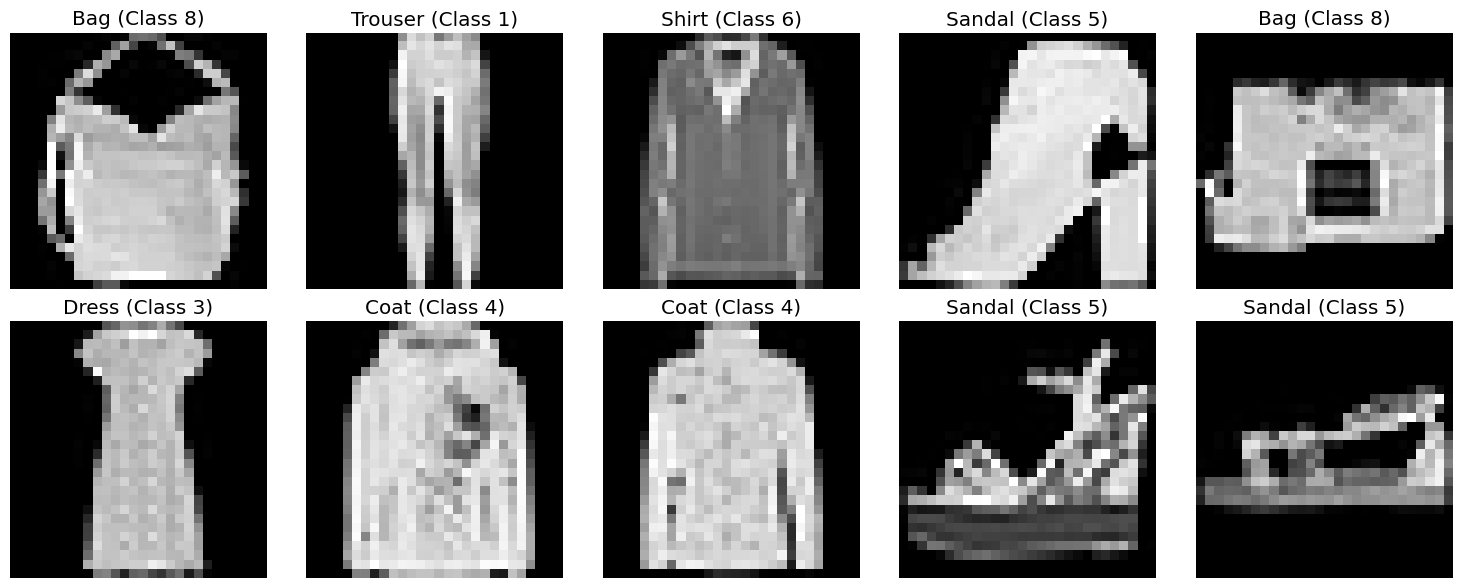

In [7]:
# Define data transforms for preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),                      # Convert PIL Image to tensor (0-255 → 0-1)
    transforms.Normalize((0.2860,), (0.3530,))  # Normalize with Fashion-MNIST mean and std
])

# Fashion-MNIST class names for visualization
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print("📥 Loading Fashion-MNIST dataset...")

# Load training dataset
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data',           # Directory to store data
    train=True,              # Load training set
    download=True,           # Download if not already present
    transform=transform      # Apply preprocessing transforms
)

# Load test dataset
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,             # Load test set
    download=True,
    transform=transform
)

# Create data loaders for efficient batching
batch_size = 64  # Number of samples per batch

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,            # Shuffle training data for better learning
    num_workers=2            # Parallel data loading
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,           # No need to shuffle test data
    num_workers=2
)

print("✅ Dataset loading complete!")
print(f"\n📊 Dataset Statistics:")
print(f"   Training samples: {len(train_dataset):,}")
print(f"   Test samples: {len(test_dataset):,}")
print(f"   Number of classes: {len(class_names)}")
print(f"   Batch size: {batch_size}")
print(f"   Training batches: {len(train_loader):,}")
print(f"   Test batches: {len(test_loader):,}")

# Visualize some samples from the dataset
def show_samples(dataloader, num_samples=10):
    """Display sample images from a dataloader with their labels."""
    data_iter = iter(dataloader)
    images, labels = next(data_iter)

    # Create a grid of images
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()

    for i in range(num_samples):
        img = images[i].squeeze().numpy()
        label = labels[i].item()

        # Plot the image
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"{class_names[label]} (Class {label})")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Show 10 sample images
show_samples(train_loader)

### **4.2 Training the CNN Model**

Now let's define the training process and train our CNN model on the Fashion-MNIST dataset:

In [8]:
# !pip install ipywidgets
%pip install ipywidgets

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


Epoch 1/5:   0%|          | 0/938 [00:00<?, ?it/s]


Epoch 1/5
Train Loss: 0.5601, Train Accuracy: 79.67%


Epoch 2/5:   0%|          | 0/938 [00:00<?, ?it/s]


Epoch 2/5
Train Loss: 0.3492, Train Accuracy: 87.54%


Epoch 3/5:   0%|          | 0/938 [00:00<?, ?it/s]


Epoch 3/5
Train Loss: 0.2988, Train Accuracy: 89.31%


Epoch 4/5:   0%|          | 0/938 [00:00<?, ?it/s]


Epoch 4/5
Train Loss: 0.2648, Train Accuracy: 90.49%


Epoch 5/5:   0%|          | 0/938 [00:00<?, ?it/s]


Epoch 5/5
Train Loss: 0.2412, Train Accuracy: 91.36%

Training complete in 139.02 seconds


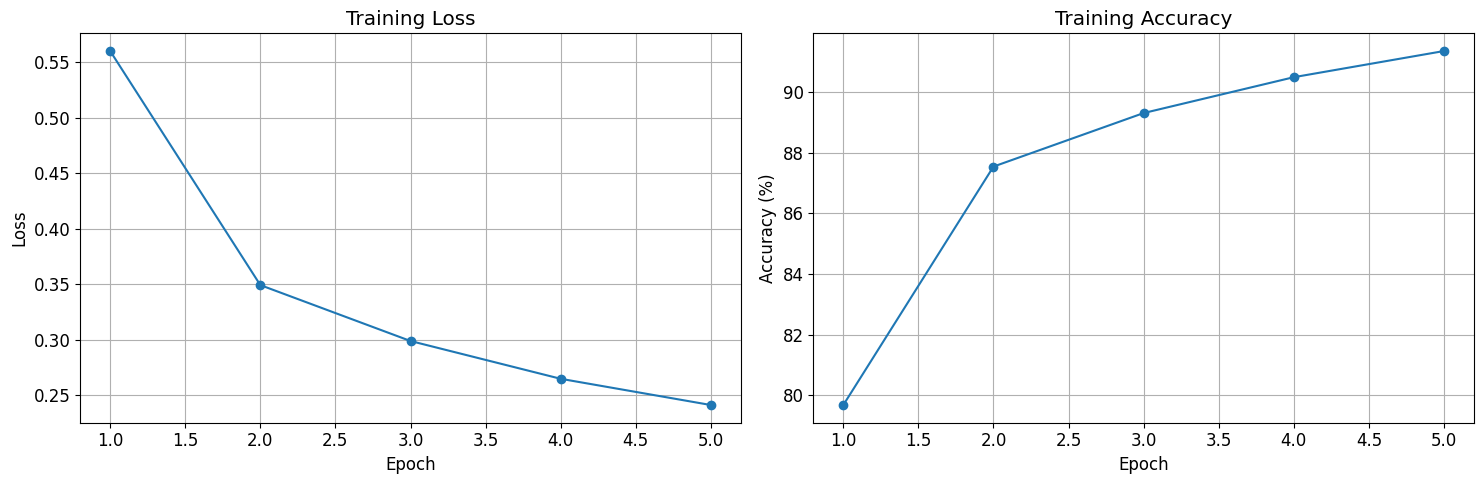

In [9]:
# Initialize a new model and move it to the device
model = SimpleCNN().to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()  # Standard loss for multi-class classification
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam optimizer

# Training function
def train_model(model, train_loader, criterion, optimizer, num_epochs=5):
    """Train the model on the training data."""
    # Lists to store metrics for visualization
    train_losses = []
    train_accuracies = []

    # Start timer
    start_time = time.time()

    # Iterate over epochs
    for epoch in range(num_epochs):
        # Set model to training mode
        model.train()

        # Tracking metrics
        running_loss = 0.0
        correct = 0
        total = 0

        # Progress bar for current epoch
        progress_bar = tqdm(enumerate(train_loader), total=len(train_loader),
                           desc=f"Epoch {epoch+1}/{num_epochs}")

        # Iterate over batches
        for i, (inputs, labels) in progress_bar:
            # Move data to device
            inputs, labels = inputs.to(device), labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            # Update statistics
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            # Update progress bar
            avg_loss = running_loss / (i + 1)
            accuracy = 100. * correct / total
            progress_bar.set_postfix({
                'loss': f"{avg_loss:.4f}",
                'accuracy': f"{accuracy:.2f}%"
            })

        # Calculate epoch metrics
        epoch_loss = running_loss / len(train_loader)
        epoch_accuracy = 100. * correct / total

        # Store metrics for plotting
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_accuracy)

        # Print epoch statistics
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print(f"Train Loss: {epoch_loss:.4f}, Train Accuracy: {epoch_accuracy:.2f}%")

    # Calculate and print training time
    elapsed_time = time.time() - start_time
    print(f"\nTraining complete in {elapsed_time:.2f} seconds")

    return train_losses, train_accuracies

# Import the time module for measuring training time
import time
from tqdm.notebook import tqdm

# Train the model (we'll use fewer epochs for demonstration)
num_epochs = 5  # Increase for better results
train_losses, train_accuracies = train_model(model, train_loader, criterion, optimizer, num_epochs=num_epochs)

# Plot training metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot loss
ax1.plot(range(1, num_epochs + 1), train_losses, marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.grid(True)

# Plot accuracy
ax2.plot(range(1, num_epochs + 1), train_accuracies, marker='o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training Accuracy')
ax2.grid(True)

plt.tight_layout()
plt.show()

### **4.3 Evaluating the CNN Model**

After training, we need to evaluate our model on the test set to see how well it generalizes to unseen data:

Evaluating:   0%|          | 0/157 [00:00<?, ?it/s]

Test Loss: 0.2594
Test Accuracy: 90.91%
Correct predictions: 9091/10000


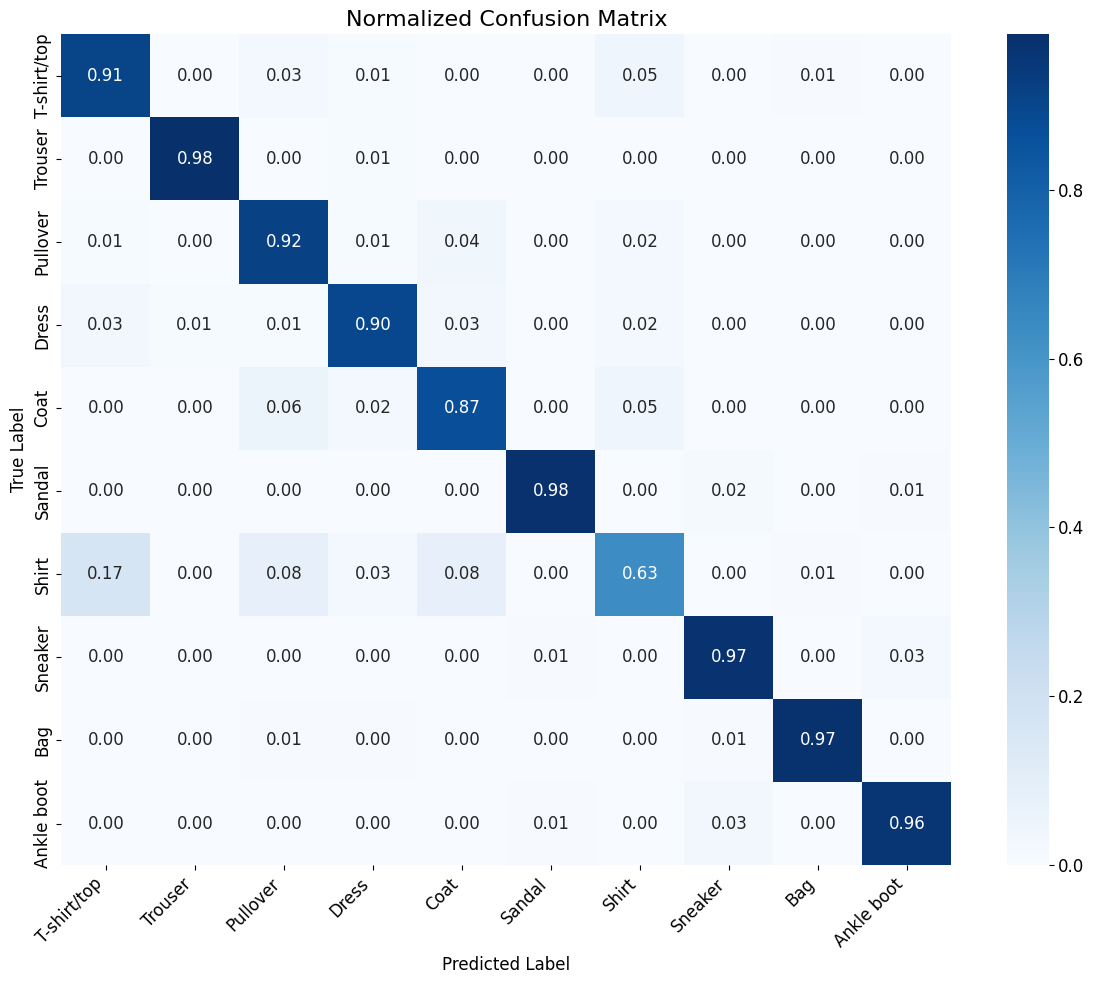

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top      0.809     0.908     0.856      1000
     Trouser      0.987     0.984     0.985      1000
    Pullover      0.832     0.915     0.871      1000
       Dress      0.918     0.897     0.907      1000
        Coat      0.842     0.871     0.856      1000
      Sandal      0.986     0.979     0.982      1000
       Shirt      0.814     0.631     0.711      1000
     Sneaker      0.949     0.970     0.959      1000
         Bag      0.987     0.973     0.980      1000
  Ankle boot      0.970     0.963     0.966      1000

    accuracy                          0.909     10000
   macro avg      0.909     0.909     0.908     10000
weighted avg      0.909     0.909     0.908     10000



In [16]:
# Evaluate the model on the test set
def evaluate_model(model, test_loader, criterion):
    """Evaluate the model on the test set."""
    # Set model to evaluation mode
    model.eval()

    # Tracking metrics
    test_loss = 0.0
    correct = 0
    total = 0

    # Store all predictions and targets for confusion matrix
    all_predictions = []
    all_targets = []

    # No gradients needed for evaluation
    with torch.no_grad():
        for inputs, targets in tqdm(test_loader, desc="Evaluating"):
            # Move data to device
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward pass
            outputs = model(inputs)

            # Calculate loss
            loss = criterion(outputs, targets)
            test_loss += loss.item()

            # Get predictions
            _, predicted = outputs.max(1)

            # Update statistics
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

            # Store for confusion matrix
            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    # Calculate metrics
    test_loss /= len(test_loader)
    test_accuracy = 100. * correct / total

    # Print results
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.2f}%")
    print(f"Correct predictions: {correct}/{total}")

    return test_loss, test_accuracy, all_predictions, all_targets

# Run evaluation
test_loss, test_accuracy, all_predictions, all_targets = evaluate_model(model, test_loader, criterion)

# Create and plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
    """Create and plot a confusion matrix."""
    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Normalize by row (true labels)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Plot
    plt.figure(figsize=(12, 10))

    # Create a heatmap
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)

    plt.title('Normalized Confusion Matrix', fontsize=16)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Print classification report
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

# Plot confusion matrix
plot_confusion_matrix(all_targets, all_predictions, class_names)

## **5. Visualizing CNN Features and Filters**

One of the most valuable aspects of CNNs is their interpretability. We can visualize what features the network is learning at different layers, helping us understand how CNNs process images.

### **5.1 Visualizing Learned Feature Maps**

Feature maps show the activation patterns of different filters applied to an input image. Let's visualize some feature maps from our trained model:

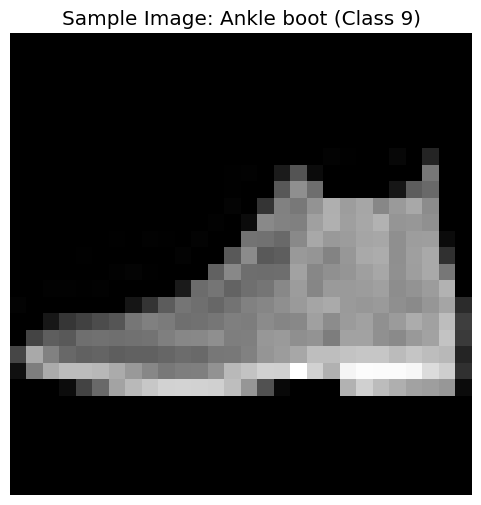

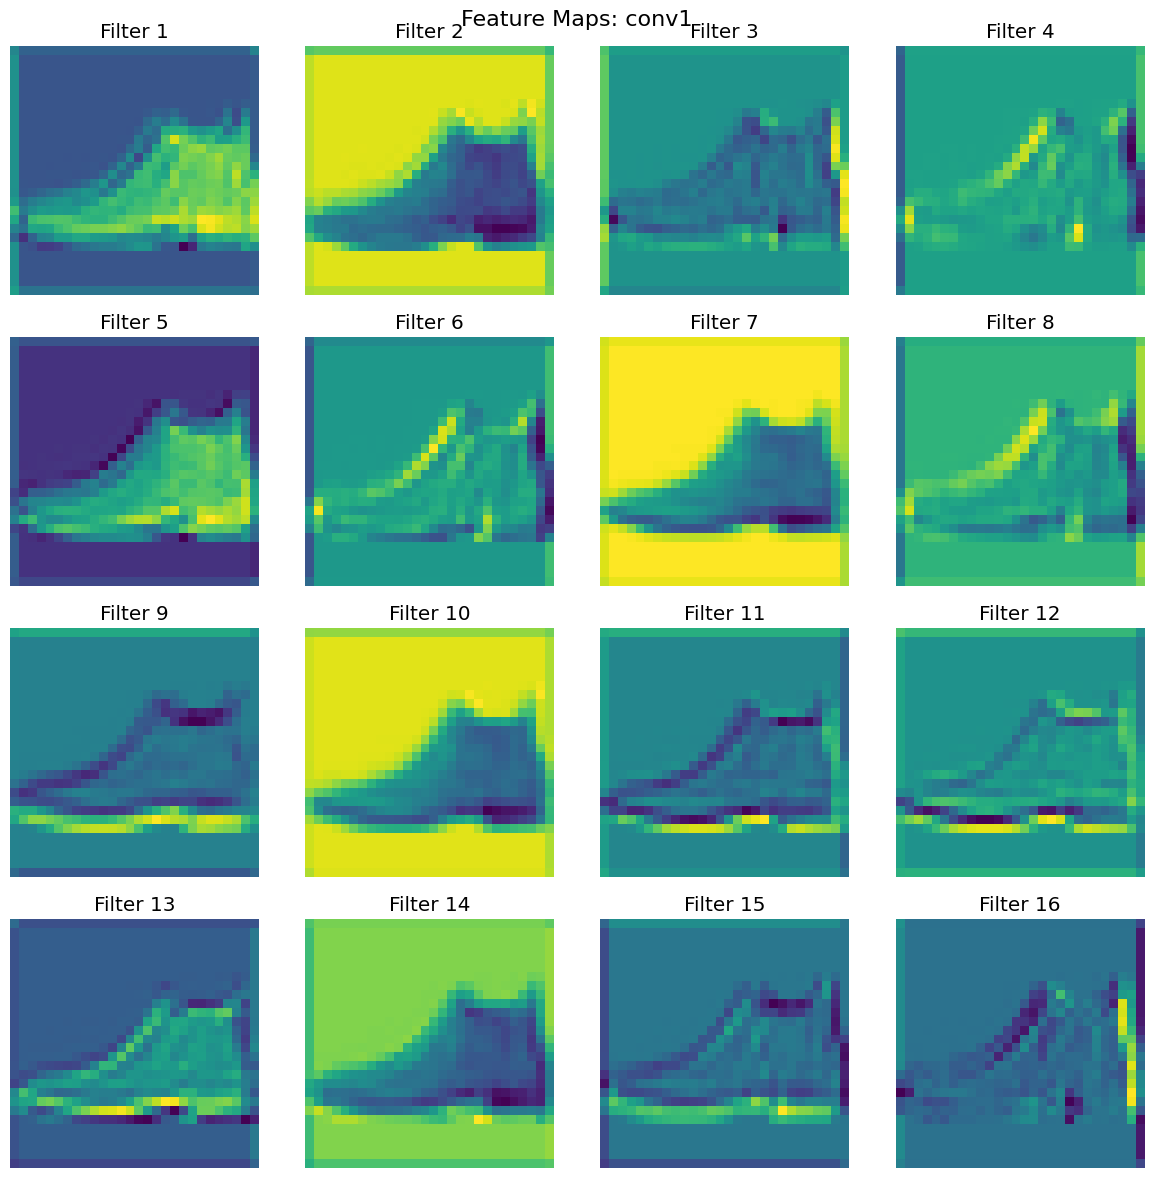

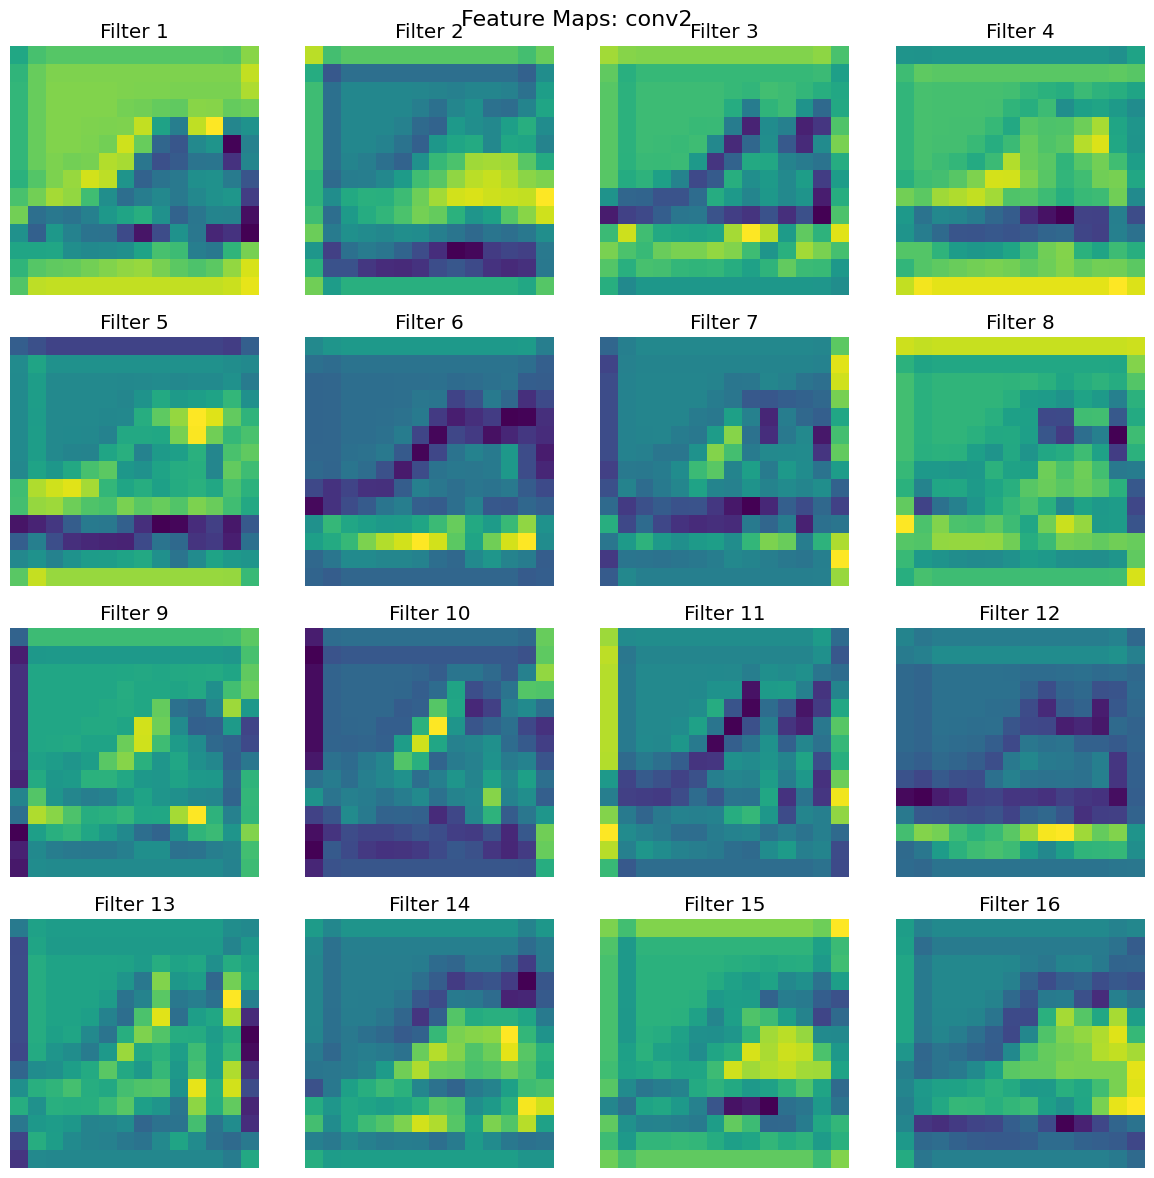

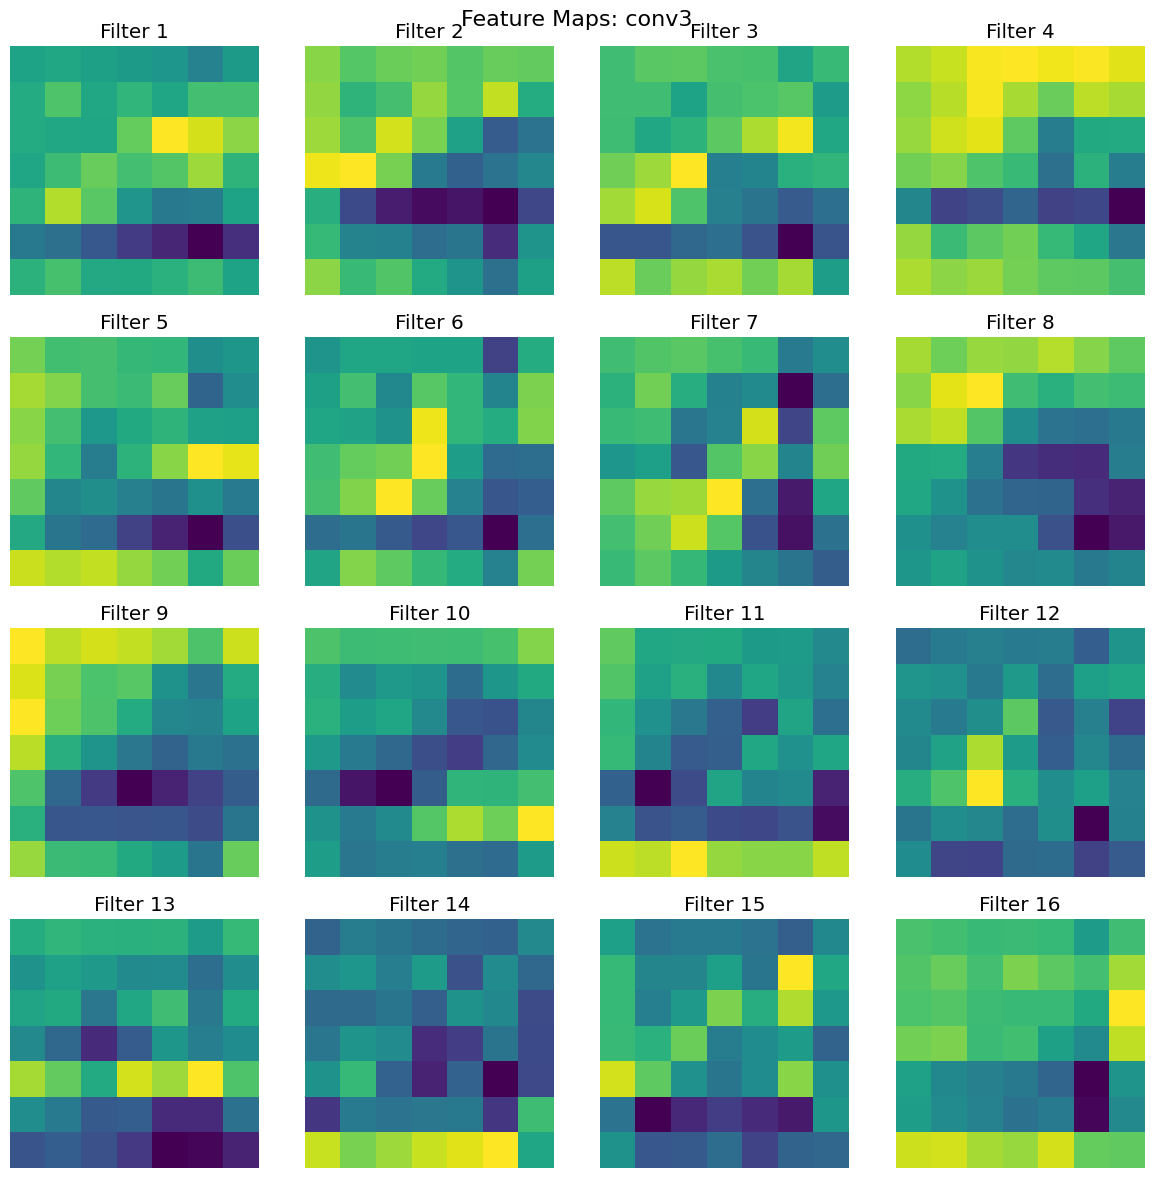

In [17]:
# Get a single test image
data_iter = iter(test_loader)
images, labels = next(data_iter)
sample_image = images[0:1].to(device)  # Add batch dimension and move to device
sample_label = labels[0].item()
sample_class = class_names[sample_label]

# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(sample_image[0, 0].cpu().numpy(), cmap='gray')
plt.title(f"Sample Image: {sample_class} (Class {sample_label})")
plt.axis('off')
plt.show()

# Extract feature maps
model.eval()  # Set to evaluation mode
feature_maps = model.feature_maps(sample_image)

# Visualize feature maps from each layer
def plot_feature_maps(feature_maps, layer_name, num_features=8):
    """Visualize feature maps from a specific layer."""
    # Get the feature maps for this layer
    features = feature_maps[layer_name][0].cpu().detach().numpy()

    # Determine grid size (try to make it square-ish)
    n_features = min(num_features, features.shape[0])
    grid_size = int(np.ceil(np.sqrt(n_features)))

    # Create figure
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(12, 12))
    axes = axes.flatten()

    # Plot each feature map
    for i in range(grid_size * grid_size):
        if i < n_features:
            # Normalize feature map for better visualization
            feature = features[i]
            feature = (feature - feature.min()) / (feature.max() - feature.min() + 1e-8)

            # Display
            axes[i].imshow(feature, cmap='viridis')
            axes[i].set_title(f"Filter {i+1}")
        axes[i].axis('off')

    plt.suptitle(f"Feature Maps: {layer_name}", fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()

# Visualize feature maps from different layers
plot_feature_maps(feature_maps, 'conv1', num_features=16)
plot_feature_maps(feature_maps, 'conv2', num_features=16)
plot_feature_maps(feature_maps, 'conv3', num_features=16)

### **5.2 Visualizing Learned Filters**

Convolutional filters (kernels) show what patterns the network is looking for in the input. First-layer filters are particularly interpretable as they operate directly on the input image:

In [18]:
# Visualize the filters from the first convolutional layer
def visualize_filters(model, layer_name='conv1', num_filters=16):
    """Visualize the filters (weights) of a convolutional layer."""
    # Get the convolutional layer
    if layer_name == 'conv1':
        conv_layer = model.conv1
    elif layer_name == 'conv2':
        conv_layer = model.conv2
    elif layer_name == 'conv3':
        conv_layer = model.conv3
    else:
        raise ValueError(f"Layer {layer_name} not found in the model")

    # Get the weights
    weights = conv_layer.weight.data.cpu().numpy()

    # Determine how many filters to show
    n_filters = min(num_filters, weights.shape[0])

    # Calculate grid size
    grid_size = int(np.ceil(np.sqrt(n_filters)))

    # Create figure
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(12, 12))
    axes = axes.flatten()

    # Plot each filter
    for i in range(grid_size * grid_size):
        if i < n_filters:
            # For first layer, we can visualize directly (weights connect to input)
            if layer_name == 'conv1':
                img = weights[i, 0]  # First channel only for grayscale input
            else:
                # For deeper layers, take the average across input channels
                img = np.mean(weights[i], axis=0)

            # Normalize for better visualization
            img = (img - img.min()) / (img.max() - img.min() + 1e-8)

            # Display
            axes[i].imshow(img, cmap='viridis')
            axes[i].set_title(f"Filter {i+1}")
            for k in range(img.shape[0]):
              for l in range(img.shape[1]):
                  axes[i].text(l, k, f'{img[k, l]:0.4f}', ha='center', va='center', color='white', fontsize=12)
        axes[i].axis('off')

    plt.suptitle(f"Learned Filters: {layer_name}", fontsize=16)
    plt.tight_layout()
    plt.show()

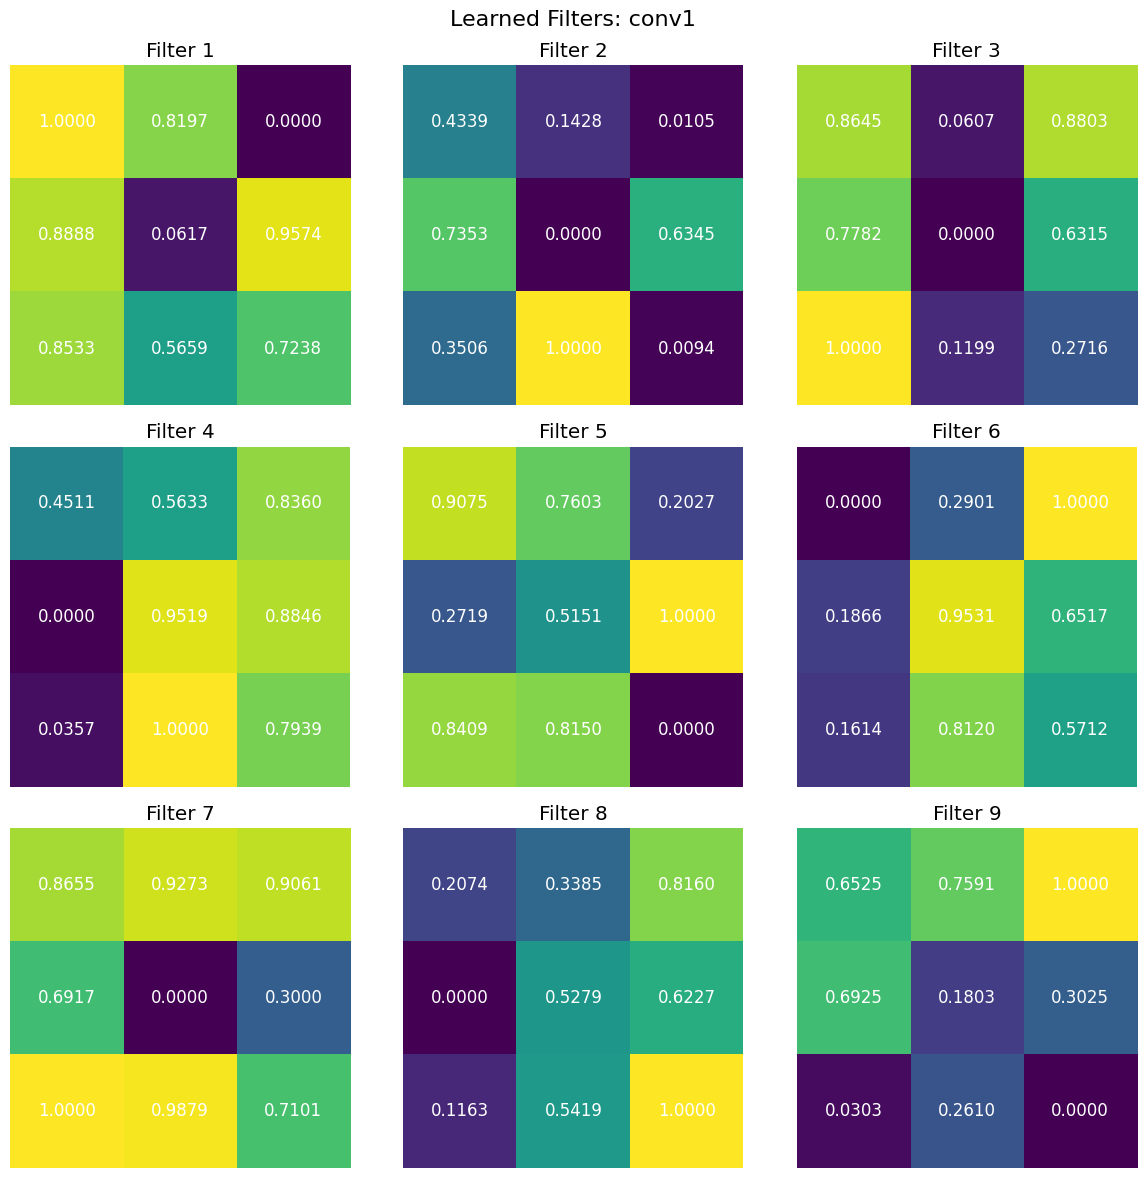

In [19]:
# Visualize filters from first layer
visualize_filters(model, 'conv1', 9)

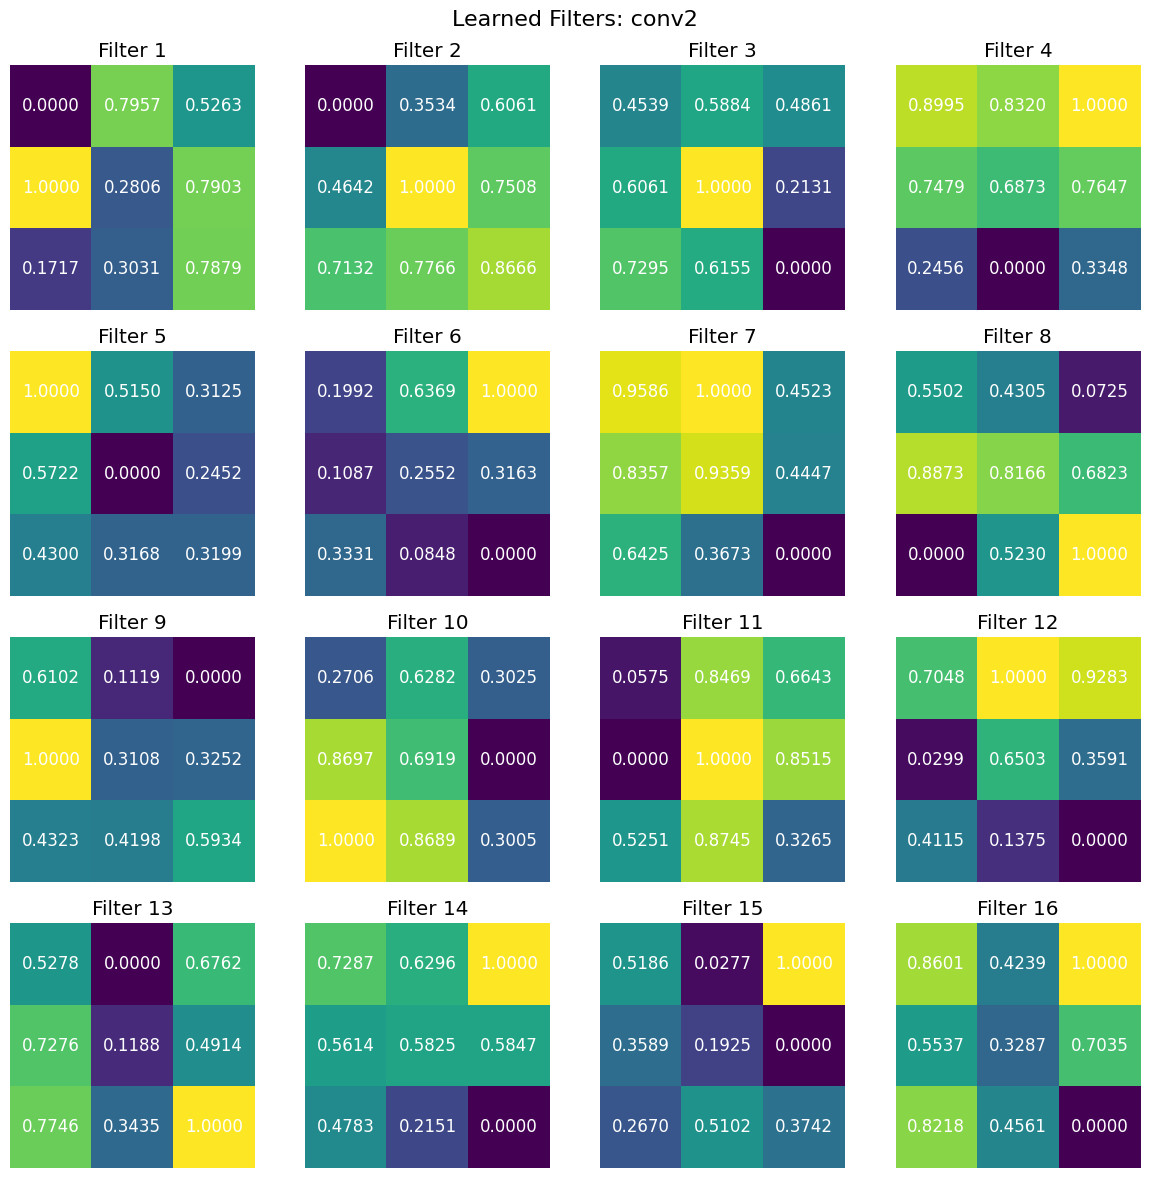

In [20]:
# Visualize filters from second layer (average across input channels)
visualize_filters(model, 'conv2', 16)

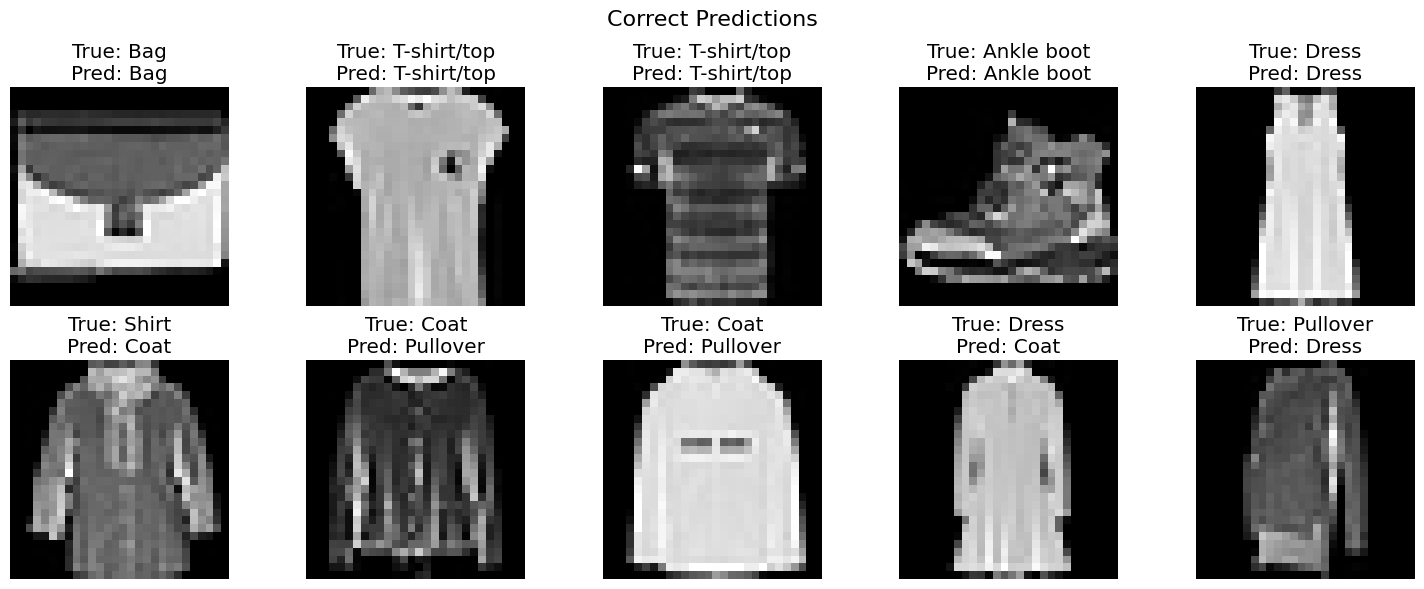

In [23]:
# Let's look at some correctly and incorrectly classified examples
def show_predictions(model, dataloader, class_names, num_samples=20):
    """Show examples of correct and incorrect predictions."""
    model.eval()
    all_images = []
    all_labels = []
    all_preds = []

    # Collect a batch of images
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            # Convert to CPU and numpy
            all_images.extend(images.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

            if len(all_images) >= 100:  # Collect enough samples
                break

    # Find correct and incorrect predictions
    correct_idx = [i for i, (pred, label) in enumerate(zip(all_preds, all_labels)) if pred == label]
    incorrect_idx = [i for i, (pred, label) in enumerate(zip(all_preds, all_labels)) if pred != label]

    # Choose random samples
    np.random.shuffle(correct_idx)
    np.random.shuffle(incorrect_idx)

    # Display correct predictions
    plt.figure(figsize=(15, 6))
    plt.suptitle("Correct Predictions", fontsize=16)
    for i, idx in enumerate(correct_idx[:5]):
        plt.subplot(2, 5, i+1)
        plt.imshow(all_images[idx][0], cmap='gray')
        plt.title(f"True: {class_names[all_labels[idx]]}\nPred: {class_names[all_preds[idx]]}")
        plt.axis('off')

    # Display incorrect predictions
    for i, idx in enumerate(incorrect_idx[:5]):
        plt.subplot(2, 5, i+6)
        plt.imshow(all_images[idx][0], cmap='gray')
        plt.title(f"True: {class_names[all_labels[idx]]}\nPred: {class_names[all_preds[idx]]}")
        plt.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()

# Show examples
show_predictions(model, test_loader, class_names)